# Clase 2: Analisis exploratorio y procesamiento de datos

**Analitica de Datos**, Maestria en Ciencias del Comportamiento, Universidad de San Andres, Primavera 2026

**Lenguaje: R.** Esta es la version R, equivalente y validada, de la notebook Python de la clase: mismo dataset, mismos pasos, mismos resultados. Usala si te sentis mas comodo/a en R; el dictado sigue la version Python.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdamelio/analitica_de_datos/blob/main/clases/clase-02/notebooks/clase02_r.ipynb)

**Objetivo.** Recorrer el analisis exploratorio (EDA) completo de la clase con el R que ya conoces (tidyverse), articulando lo visto en Estadistica con las practicas que piden los proyectos de machine learning.

**Al terminar esta clase vas a poder:**

- cargar un dataset real desde la nube y explorarlo con `readr` y `dplyr`;
- calcular descriptivos, filtrar, ordenar, agrupar y resumir;
- detectar y tratar duplicados, valores faltantes y outliers, justificando cada decision;
- crear variables nuevas con sentido sustantivo (feature engineering);
- mapear cada verbo de `dplyr` a su equivalente en pandas, para moverte entre lenguajes.

*El codigo esta casi completo, los ejercicios tienen huecos para pensar, y las soluciones estan disponibles.*

In [1]:
# Identidad visual de la materia (ejecutar y seguir)
IRdisplay::display_html("
<style>
@import url('https://fonts.googleapis.com/css2?family=Work+Sans:wght@400;600&family=Amiri:wght@400;700&display=swap');
.rendered_html, .markdown, .cell .text_cell_render { font-family:'Work Sans',system-ui,sans-serif; color:#122535; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { font-family:'Amiri',Georgia,serif; color:#00529B; }
.rendered_html h2 { border-bottom:2px solid #00529B; padding-bottom:.2em; }
.rendered_html a { color:#00529B; }
.rendered_html table th { background:#00529B; color:#fff; }
</style>")

## Contenidos de hoy

| # | Tema | La idea en una linea |
|---|------|----------------------|
| 1 | [El R que ya sabes, como punto de partida](#s1) | tu tidyverse es el mapa para leer pandas |
| 2 | [Cargar datos desde la nube](#s2) | un tibble es una tabla con superpoderes |
| 3 | [Exploracion inicial y descriptivos](#s3) | antes de modelar, mirar; antes de mirar, resumir |
| 4 | [Procesamiento con dplyr](#s4) | filtrar, ordenar y agrupar son el 80% del trabajo real |
| 5 | [Faltantes y duplicados](#s5) | primero detectar y entender, despues decidir |
| 6 | [Outliers](#s6) | atipico no es sinonimo de error |
| 7 | [Agrupar para comparar y feature engineering](#s7) | las mejores variables se crean con conocimiento del dominio |
| 8 | [Terminologia](#s8) | limpieza, procesamiento y preprocesamiento no son lo mismo |
|  | [Autoevaluacion](#quiz), [Cierre](#cierre) | |

*Tip: hace click en cualquier tema para saltar directo.* Los ejercicios estan intercalados en la seccion que les corresponde.

## Donde se ubica esta clase en la materia

En la Clase 1 pusiste en marcha Google Colab. Hoy recorres, de punta a punta, la primera etapa de todo proyecto de datos: el analisis exploratorio. Esta version esta escrita en el R que ya usaste en Estadistica y Metodologia, con una mision extra: cada operacion lleva al lado su equivalente en pandas, para que la version Python nunca te resulte ajena.

**Sobre que se apoya.** Los descriptivos y la lectura de distribuciones de Estadistica, y tu manejo de tidyverse.

**A que habilita.** La Clase 3 (visualizacion) parte del dataset que hoy dejamos explorado y limpio. Las clases 4 a 10 reutilizan este dataset y las decisiones de limpieza que tomes hoy.

| se apoya en | esta clase | habilita |
|---|---|---|
| Estadistica descriptiva; tidyverse; Colab (Clase 1) | EDA completo: cargar, explorar, limpiar, transformar | Visualizacion (Clase 3); modelado supervisado y no supervisado (Clases 4 a 10) |

## El hilo de hoy

Una pregunta de people analytics guia toda la clase: **quienes dejan la empresa y por que**. Repaso de los verbos de dplyr $\to$ cargar el dataset real de rotacion de personal $\to$ primeros descriptivos $\to$ filtrar, ordenar y agrupar $\to$ detectar duplicados y faltantes $\to$ decidir que hacer con los outliers $\to$ crear variables nuevas que capturen el fenomeno $\to$ una tabla lista para visualizar (Clase 3) y modelar (Clase 4).

In [2]:
# Setup: librerias, semilla, estilo de figuras y helpers de la materia
suppressPackageStartupMessages(library(tidyverse))

SEED <- 42
set.seed(SEED)

# Paleta semantica de la materia (misma que la version Python y el sitio)
COL <- c(
  primary = "#00529B",  # azul institucional: la serie principal
  accent  = "#C0492F",  # terracota: el contraste
  good    = "#1F7A4D",  # verde: correcto / esperado
  bad     = "#B4232E",  # rojo: problema / alerta
  muted   = "#7E9EBB",  # azul apagado: geometria secundaria
  ink     = "#122535",  # tinta: texto y ejes
  grey    = "#9FB0BD"   # gris azulado: grillas
)
theme_set(
  theme_minimal(base_size = 12) +
    theme(plot.title = element_text(face = "bold", size = 12, colour = COL[["ink"]]),
          panel.grid.minor = element_blank())
)
options(repr.plot.width = 7, repr.plot.height = 4)

# En Colab las figuras se guardan en ./figures; al renderizar el sitio, en assets de la clase
en_colab <- file.exists("/content")
fig_dir <- if (en_colab) "figures" else "../assets/figures"
dir.create(fig_dir, showWarnings = FALSE, recursive = TRUE)

guardar_figura <- function(nombre, plot = last_plot()) {
  # Sufijo _r: la figura equivalente de la version Python es la canonica del sitio
  ggsave(file.path(fig_dir, paste0(nombre, "_r.png")), plot = plot,
         dpi = 150, width = 7, height = 4, bg = "white")
}

# URL publica y estable del dataset (repo oficial de IBM); la cargamos en la seccion 2
URL_DATOS <- "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
cat("Setup listo. Semilla fija en", SEED, "\n")

Setup listo. Semilla fija en 42 


<a name="s1"></a>
## 1. El R que ya sabes, como punto de partida

**La idea.** No arrancas de cero: los verbos de `dplyr` que usaste en Estadistica son exactamente las operaciones que todo EDA necesita, en cualquier lenguaje. Esta seccion repasa las piezas basicas con ejemplos de people analytics y te deja el diccionario R $\leftrightarrow$ Python que vamos a usar toda la materia.

| en R (tidyverse) | en Python (pandas) | que hace |
|---|---|---|
| `x <- 42` | `x = 42` | asignar una variable |
| `c(29, 41, 35)` | `[29, 41, 35]` | coleccion ordenada |
| `list(nombre = "Ana")` | `{"nombre": "Ana"}` | coleccion con nombres |
| `select(df, a, b)` | `df[["a", "b"]]` | elegir columnas |
| `filter(df, cond)` | `df[cond]` | filtrar filas |
| `arrange(df, desc(a))` | `df.sort_values("a", ascending=False)` | ordenar |
| `mutate(df, c = a/b)` | `df["c"] = df["a"] / df["b"]` | crear columna |
| `group_by() + summarise()` | `df.groupby("g")["x"].mean()` | agrupar y resumir |

Una diferencia para tener a mano: **R cuenta desde 1 y Python desde 0**. `edades[1]` es el primer elemento en R y el segundo en Python.

### Las piezas basicas, en miniatura

Antes del dataset real, la logica de un analisis en cuatro objetos: un vector, una lista nombrada (el "diccionario" de R), un bucle y una funcion.

In [3]:
# Un vector: edades de un equipo de 6 personas
edades <- c(29, 41, 35, 52, 27, 38)
cat("Primera edad:", edades[1], "| ultima:", edades[length(edades)], "| cuantas:", length(edades), "\n")

# Una lista nombrada: UNA empleada con sus atributos (el "diccionario" de Python)
empleada <- list(nombre = "Ana", edad = 29, ingreso = 3200.0, horas_extra = TRUE)
cat("Edad de Ana:", empleada$edad, "\n")

# Una tabla en miniatura: en R lo natural es un tibble
equipo <- tibble(
  nombre   = c("Ana", "Bruno", "Carla", "Dario"),
  ingreso  = c(3200, 5100, 2800, 6900),
  renuncio = c(TRUE, FALSE, TRUE, FALSE)
)

# Bucle y condicional: cuantas personas renunciaron
renuncias <- 0
for (i in seq_len(nrow(equipo))) {
  if (equipo$renuncio[i]) {
    renuncias <- renuncias + 1
  }
}
cat("Renuncias en el equipo:", renuncias, "de", nrow(equipo), "\n")

# La misma logica, empaquetada en una funcion reutilizable
tasa_de_renuncia <- function(tabla) {
  mean(tabla$renuncio)   # la media de un vector logico es una proporcion
}
tasa_equipo <- tasa_de_renuncia(equipo)
cat("Tasa de renuncia del equipo:", tasa_equipo, "\n")

# Verificacion: cada afirmacion de esta clase se comprueba con stopifnot()
stopifnot(edades[1] == 29, renuncias == 2, tasa_equipo == 0.5)

Primera edad: 29 | ultima: 38 | cuantas: 6 


Edad de Ana: 29 


Renuncias en el equipo: 2 de 4 


Tasa de renuncia del equipo: 0.5 


<a name="e1"></a>
### Ejercicio 1. Fundamentos: clasificar ingresos

Escribi una funcion `clasificar_ingreso(ingreso)` que devuelva `"bajo"` si el ingreso mensual es menor a 3000, `"medio"` si esta entre 3000 y 10000 (sin incluir), y `"alto"` si es 10000 o mas. Despues usala en un `for` para clasificar los ingresos de `ingresos_muestra` y contar cuantos hay de cada banda en el vector nombrado `conteo`.

*Pista: `conteo[[banda]] <- conteo[[banda]] + 1` suma 1 a la banda que corresponda.*

In [4]:
clasificar_ingreso <- function(ingreso) {
  if (ingreso < 3000) {
    "bajo"
  } else if (ingreso < 10000) {
    "medio"
  } else {
    "alto"
  }
}

ingresos_muestra <- c(2094, 5993, 2911, 19999, 4919, 2670, 13245)

conteo <- c(bajo = 0, medio = 0, alto = 0)
for (ingreso in ingresos_muestra) {
  banda <- clasificar_ingreso(ingreso)
  conteo[[banda]] <- conteo[[banda]] + 1
}

print(conteo)
stopifnot(conteo[["bajo"]] == 3, conteo[["medio"]] == 2, conteo[["alto"]] == 2)
cat("Ejercicio 1 correcto\n")

 bajo medio  alto 
    3     2     2 


Ejercicio 1 correcto


<a name="s2"></a>
## 2. Cargar datos: de un archivo en la nube a un tibble

**La idea.** Todo analisis empieza trayendo los datos a memoria. `readr::read_csv()` convierte un CSV (local o en la nube) en un tibble, igual que `pd.read_csv()` en Python.

Nuestro dataset es **HR Employee Attrition**: 1470 empleados ficticios creados por cientificos de datos de IBM para estudiar la **rotacion de personal** (*attrition*: si la persona dejo la empresa). Es EL problema clasico de people analytics. Lo cargamos directo desde el repositorio publico oficial de IBM.

Para otros formatos el patron es identico: `readxl::read_excel()` para planillas, `arrow::read_parquet()` para el formato columnar de datos grandes, y `write_csv()` y compania para exportar.

In [5]:
# Cargar el CSV desde la URL publica (funciona en Colab sin descargar nada a mano)
df <- read_csv(URL_DATOS, show_col_types = FALSE)

cat("Dimensiones (filas, columnas):", dim(df), "\n")
head(df, 3)

Dimensiones (filas, columnas): 1470 35 


Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0


In [6]:
# Verificacion: el dataset tiene 1470 empleados y 35 variables
stopifnot(nrow(df) == 1470, ncol(df) == 35, "Attrition" %in% names(df))

### Que tipo tiene cada columna

`glimpse()` resume nombre, tipo y primeros valores de cada columna (es el `df.info()` de pandas). Leer esta salida es el primer chequeo de calidad: una variable numerica que aparece como texto es sintoma de datos sucios.

In [7]:
glimpse(df)

Rows: 1,470
Columns: 35
$ Age                      <dbl> 41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 2…
$ Attrition                <chr> "Yes", "No", "Yes", "No", "No", "No", "No", "…
$ BusinessTravel           <chr> "Travel_Rarely", "Travel_Frequently", "Travel…
$ DailyRate                <dbl> 1102, 279, 1373, 1392, 591, 1005, 1324, 1358,…
$ Department               <chr> "Sales", "Research & Development", "Research …
$ DistanceFromHome         <dbl> 1, 8, 2, 3, 2, 2, 3, 24, 23, 27, 16, 15, 26, …
$ Education                <dbl> 2, 1, 2, 4, 1, 2, 3, 1, 3, 3, 3, 2, 1, 2, 3, …
$ EducationField           <chr> "Life Sciences", "Life Sciences", "Other", "L…
$ EmployeeCount            <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ EmployeeNumber           <dbl> 1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16,…
$ EnvironmentSatisfaction  <dbl> 2, 3, 4, 4, 1, 4, 3, 4, 4, 3, 1, 4, 1, 2, 3, …
$ Gender                   <chr> "Female", "Male", "Male", "Female", "Male", "…
$ HourlyRate    

In [8]:
# Cuantas columnas numericas y cuantas de texto hay
numericas <- names(df)[sapply(df, is.numeric)]
texto <- names(df)[sapply(df, is.character)]
cat(length(numericas), "columnas numericas |", length(texto), "columnas de texto\n")
cat("De texto:", paste(texto, collapse = ", "), "\n")

stopifnot(length(numericas) == 26, length(texto) == 9)

26 columnas numericas | 9 columnas de texto


De texto: Attrition, BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, Over18, OverTime 


<a name="s3"></a>
## 3. Exploracion inicial y descriptivos

**La idea.** Antes de cualquier modelo, numeros que resuman: cuantos casos hay, como se distribuye la variable de interes, que pinta tienen las demas. `summary()` calcula los descriptivos que ya conoces; `count()` cuenta categorias.

**Predeci antes de correr la proxima celda:** en una distribucion de ingresos, la media suele ser mayor, menor o igual que la mediana?

<details><summary>Ver la respuesta</summary>

Mayor. Los ingresos casi siempre tienen **asimetria a derecha**: una minoria gana mucho y arrastra la media hacia arriba, mientras la mediana se queda con la mayoria. Por eso para ingresos se reporta mediana. Confirmalo en la celda siguiente.

</details>

In [9]:
# Descriptivos de las variables centrales de hoy
df %>%
  select(Age, MonthlyIncome, YearsAtCompany, DistanceFromHome) %>%
  summary()

      Age        MonthlyIncome   YearsAtCompany   DistanceFromHome
 Min.   :18.00   Min.   : 1009   Min.   : 0.000   Min.   : 1.000  
 1st Qu.:30.00   1st Qu.: 2911   1st Qu.: 3.000   1st Qu.: 2.000  
 Median :36.00   Median : 4919   Median : 5.000   Median : 7.000  
 Mean   :36.92   Mean   : 6503   Mean   : 7.008   Mean   : 9.193  
 3rd Qu.:43.00   3rd Qu.: 8379   3rd Qu.: 9.000   3rd Qu.:14.000  
 Max.   :60.00   Max.   :19999   Max.   :40.000   Max.   :29.000  

In [10]:
# La variable objetivo: cuantos se fueron?
conteo_attrition <- df %>% count(Attrition)
print(conteo_attrition)

tasa_attrition <- mean(df$Attrition == "Yes")
mediana_ingreso <- median(df$MonthlyIncome)
media_ingreso <- mean(df$MonthlyIncome)
cat("Tasa de rotacion:", round(tasa_attrition * 100, 1), "% | ingreso mediano: $",
    mediana_ingreso, "| ingreso medio: $", round(media_ingreso), "\n")

# Verificaciones (calculo independiente del conteo)
stopifnot(
  conteo_attrition$n[conteo_attrition$Attrition == "Yes"] == 237,
  conteo_attrition$n[conteo_attrition$Attrition == "No"] == 1233,
  abs(tasa_attrition - 237/1470) < 1e-12,
  mediana_ingreso == 4919,
  media_ingreso > mediana_ingreso   # asimetria a derecha, como predijiste
)

# A tibble: 2 × 2
  Attrition     n
  <chr>     <int>
1 No         1233
2 Yes         237


Tasa de rotacion: 16.1 % | ingreso mediano: $ 4919 | ingreso medio: $ 6503 


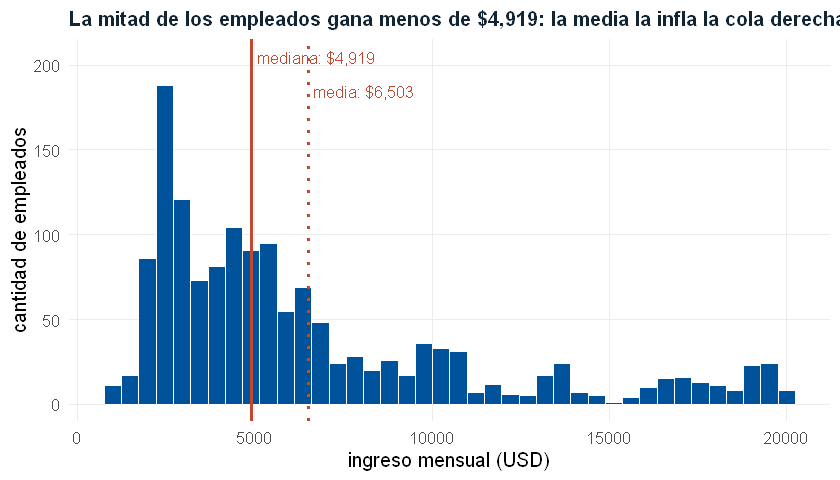

In [11]:
# Primera figura: la distribucion del ingreso mensual
p <- ggplot(df, aes(x = MonthlyIncome)) +
  geom_histogram(bins = 40, fill = COL[["primary"]], colour = "white") +
  geom_vline(xintercept = mediana_ingreso, colour = COL[["accent"]], linewidth = 1) +
  geom_vline(xintercept = media_ingreso, colour = COL[["accent"]], linewidth = 1, linetype = "dotted") +
  annotate("text", x = mediana_ingreso, y = 205, label = "mediana: $4,919",
           hjust = -0.05, colour = COL[["accent"]], size = 3.4) +
  annotate("text", x = media_ingreso, y = 185, label = "media: $6,503",
           hjust = -0.05, colour = COL[["accent"]], size = 3.4) +
  labs(title = "La mitad de los empleados gana menos de $4,919: la media la infla la cola derecha",
       x = "ingreso mensual (USD)", y = "cantidad de empleados")
guardar_figura("clase02_distribucion_ingreso", p)
p

<a name="s4"></a>
## 4. Procesamiento con dplyr: filtrar, seleccionar, ordenar, agrupar

**La idea.** El 80% del trabajo real con datos son los verbos que ya usaste mil veces: `select`, `filter`, `arrange`, `rename`, `mutate`, `group_by` + `summarise`. Hoy los aplicamos con ojo de EDA: cada operacion responde una pregunta sustantiva sobre la rotacion.

In [12]:
# Elegir columnas: la vista minima del problema
vista <- df %>% select(Age, Department, JobRole, MonthlyIncome, OverTime, Attrition)
head(vista, 3)

Age,Department,JobRole,MonthlyIncome,OverTime,Attrition
<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
41,Sales,Sales Executive,5993,Yes,Yes
49,Research & Development,Research Scientist,5130,No,No
37,Research & Development,Laboratory Technician,2090,Yes,Yes


In [13]:
# Filtrar filas: quienes hacen horas extra
con_horas_extra <- df %>% filter(OverTime == "Yes")
cat("Hacen horas extra:", nrow(con_horas_extra), "de", nrow(df), "\n")

# Ordenar: los 3 ingresos mas altos de ese grupo
con_horas_extra %>%
  arrange(desc(MonthlyIncome)) %>%
  select(JobRole, MonthlyIncome, Attrition) %>%
  head(3)

Hacen horas extra: 416 de 1470 


JobRole,MonthlyIncome,Attrition
<chr>,<dbl>,<chr>
Manager,19859,Yes
Manager,19847,No
Research Director,19701,No


In [14]:
# Verificacion del filtro: 416 personas hacen horas extra
stopifnot(nrow(con_horas_extra) == 416, all(con_horas_extra$OverTime == "Yes"))

### Limpieza estructural: columnas sin informacion y duplicados

Tres columnas de este dataset valen lo mismo en las 1470 filas: no distinguen a nadie y conviene sacarlas. `n_distinct()` las delata. De paso chequeamos duplicados exactos con `duplicated()`: aca no hay, pero en datos reales son moneda corriente.

In [15]:
# Detectar columnas constantes: un solo valor distinto en toda la columna
constantes <- names(df)[sapply(df, n_distinct) == 1]
cat("Columnas constantes:", paste(constantes, collapse = ", "), "\n")

# Sacarlas
df <- df %>% select(-all_of(constantes))
cat("Quedan", ncol(df), "columnas\n")

# Duplicados exactos
cat("Filas duplicadas:", sum(duplicated(df)), "\n")

stopifnot(
  setequal(constantes, c("EmployeeCount", "Over18", "StandardHours")),
  ncol(df) == 32,
  sum(duplicated(df)) == 0
)

Columnas constantes: EmployeeCount, Over18, StandardHours 


Quedan 32 columnas


Filas duplicadas: 0 


In [16]:
# Agrupar y resumir: ingreso mediano por departamento
ingreso_por_area <- df %>%
  group_by(Department) %>%
  summarise(mediana_ingreso = median(MonthlyIncome)) %>%
  arrange(mediana_ingreso)
print(ingreso_por_area)

stopifnot(
  ingreso_por_area$mediana_ingreso[ingreso_por_area$Department == "Human Resources"] == 3886,
  ingreso_por_area$mediana_ingreso[ingreso_por_area$Department == "Research & Development"] == 4374,
  ingreso_por_area$mediana_ingreso[ingreso_por_area$Department == "Sales"] == 5754.5
)

# A tibble: 3 × 2
  Department             mediana_ingreso
  <chr>                            <dbl>
1 Human Resources                  3886 
2 Research & Development           4374 
3 Sales                            5754.


<a name="e2"></a>
### Ejercicio 2. dplyr: donde se concentra la rotacion?

Calcula la **tasa de attrition por puesto** (`JobRole`) y mostra los 3 puestos con mayor rotacion. La receta: crea la columna logica `AttritionBool` con `Attrition == "Yes"` y usa que **la media de un vector logico es una proporcion**. Despues agrupa por `JobRole`, resumi y ordena de mayor a menor.

*Pista: `group_by(JobRole) %>% summarise(tasa = mean(AttritionBool))`.*

In [17]:
df <- df %>% mutate(AttritionBool = Attrition == "Yes")

tasa_por_puesto <- df %>%
  group_by(JobRole) %>%
  summarise(tasa = mean(AttritionBool)) %>%
  arrange(desc(tasa))

print(head(tasa_por_puesto, 3))

stopifnot(
  tasa_por_puesto$JobRole[1] == "Sales Representative",
  abs(tasa_por_puesto$tasa[1] - 0.3976) < 1e-3
)
cat("Ejercicio 2 correcto\n")

# A tibble: 3 × 2
  JobRole                tasa
  <chr>                 <dbl>
1 Sales Representative  0.398
2 Laboratory Technician 0.239
3 Human Resources       0.231


Ejercicio 2 correcto


Casi 4 de cada 10 representantes de ventas se van: cuando en la Clase 4 predigas attrition, el puesto va a ser una de las variables con mas señal. Eso es lo que busca el EDA: saber donde mirar antes de modelar.

<a name="s5"></a>
## 5. Datos faltantes y duplicados: detectar antes de decidir

**La idea.** Los datos reales llegan sucios: encuestas a medio responder, sensores que se apagan, exportaciones que duplican filas. La regla profesional es **primero detectar y entender el patron, despues decidir**; borrar a ciegas puede sesgar el analisis.

> **Nota de laboratorio.** Este dataset viene limpio de fabrica, asi que para practicar vamos a ensuciar una **copia** con reglas fijas y a la vista (nada de azar: son las mismas filas que se ensucian en la version Python, para que puedas comparar). Todo el analisis sustantivo de las otras secciones usa siempre los datos originales.

In [18]:
# Construir la copia "sucia": duplicados + faltantes con reglas deterministas
df_sucio <- bind_rows(df, head(df, 5))   # 5 filas repetidas al final
cat("Filas con duplicados:", nrow(df_sucio), "| duplicados detectados:", sum(duplicated(df_sucio)), "\n")

df_sucio <- distinct(df_sucio)
cat("Tras eliminar duplicados:", nrow(df_sucio), "filas\n")

# Reglas fijas: se pierden datos segun el numero de legajo (EmployeeNumber)
df_sucio$DistanceFromHome[df_sucio$EmployeeNumber %% 20 == 0] <- NA
df_sucio$JobSatisfaction[df_sucio$EmployeeNumber %% 31 == 0] <- NA

stopifnot(nrow(df_sucio) == 1470)

Filas con duplicados: 1475 | duplicados detectados: 5 


Tras eliminar duplicados: 1470 filas


In [19]:
# Detectar: cuantos faltantes hay, y donde
faltantes <- colSums(is.na(df_sucio))
print(faltantes[faltantes > 0])
cat("Total de celdas faltantes:", sum(is.na(df_sucio)), "\n")

stopifnot(
  sum(is.na(df_sucio$DistanceFromHome)) == 77,
  sum(is.na(df_sucio$JobSatisfaction)) == 44,
  sum(is.na(df_sucio)) == 121
)

DistanceFromHome  JobSatisfaction 
              77               44 


Total de celdas faltantes: 121 


### Decidir: eliminar o imputar

Dos familias de estrategias, cada una con su costo:

- **Eliminar** (`drop_na()`): simple y honesta, pero tira informacion; con 77 + 44 faltantes perderias hasta 121 filas de 1470, un 8%.
- **Imputar** (rellenar con un valor razonable): para una variable numerica asimetrica como la distancia, la **mediana** (robusta a outliers); para una ordinal como la satisfaccion, la **moda**.

La eleccion depende de cuanto falta, de por que falta y de que vas a hacer despues. En la Clase 4 vas a ver la version para machine learning: la imputacion se aprende **solo del set de entrenamiento**, para no filtrar informacion del test.

In [20]:
# Imputar: mediana para la distancia, moda para la satisfaccion
mediana_dist <- median(df_sucio$DistanceFromHome, na.rm = TRUE)
moda_satisf <- as.numeric(names(which.max(table(df_sucio$JobSatisfaction))))
cat("Mediana de distancia:", mediana_dist, "| moda de satisfaccion:", moda_satisf, "\n")

df_imputado <- df_sucio %>%
  mutate(
    DistanceFromHome = coalesce(DistanceFromHome, mediana_dist),  # coalesce = fillna
    JobSatisfaction  = coalesce(JobSatisfaction, moda_satisf)
  )

cat("Faltantes despues de imputar:", sum(is.na(df_imputado)), "\n")

stopifnot(
  mediana_dist == 7, moda_satisf == 4,
  sum(is.na(df_imputado)) == 0,
  median(df_imputado$DistanceFromHome) == 7   # la mediana no se movio
)

Mediana de distancia: 7 | moda de satisfaccion: 4 


Faltantes despues de imputar: 0 


<a name="e3"></a>
### Ejercicio 3. Faltantes: imputacion por grupo

Imputar con la mediana global es razonable, pero se puede afinar: conviene imputar cada faltante con la **mediana de su propio departamento**. Completa la imputacion por grupo: dentro de `group_by(Department)`, la `median(DistanceFromHome, na.rm = TRUE)` que calcules en `mutate()` es la del grupo de cada fila.

*Pista: `group_by(Department) %>% mutate(dist_imputada = coalesce(DistanceFromHome, median(DistanceFromHome, na.rm = TRUE)))`.*

In [21]:
df_grupo <- df_sucio %>%
  group_by(Department) %>%
  mutate(dist_imputada = coalesce(DistanceFromHome, median(DistanceFromHome, na.rm = TRUE))) %>%
  ungroup()

cat("Faltantes antes:", sum(is.na(df_sucio$DistanceFromHome)),
    "| despues:", sum(is.na(df_grupo$dist_imputada)), "\n")

stopifnot(sum(is.na(df_grupo$dist_imputada)) == 0,
          median(df_grupo$dist_imputada) == 7)
cat("Ejercicio 3 correcto\n")

Faltantes antes: 77 | despues: 0 


Ejercicio 3 correcto


<a name="s6"></a>
## 6. Outliers: atipico no es sinonimo de error

**La idea.** Un outlier es una observacion muy alejada del resto. La regla practica mas usada es la **regla del IQR**: es atipico lo que queda a mas de $1.5 \times IQR$ de los cuartiles,

$$ x > Q_3 + 1.5 \times IQR \qquad \text{o} \qquad x < Q_1 - 1.5 \times IQR $$

donde $Q_1$ y $Q_3$ son el primer y tercer cuartil e $IQR = Q_3 - Q_1$ es el rango intercuartilico, el ancho de la "caja central" que concentra la mitad de los datos.

> **La trampa clasica.** Detectar un outlier no autoriza a borrarlo. Un valor atipico puede ser un **error de carga** (una edad de 340) o un **caso real e informativo** (un director que gana 5 veces la mediana). La regla: detectar con estadistica, decidir con conocimiento del dominio.

In [22]:
# Regla del IQR sobre el ingreso mensual
q1 <- quantile(df$MonthlyIncome, 0.25)
q3 <- quantile(df$MonthlyIncome, 0.75)
iqr <- q3 - q1
limite_superior <- q3 + 1.5 * iqr
cat("Q1 =", q1, "| Q3 =", q3, "| IQR =", iqr, "| limite superior =", limite_superior, "\n")

outliers <- df %>% filter(MonthlyIncome > limite_superior)
cat("Ingresos atipicos:", nrow(outliers), "de", nrow(df), "\n")

# Quienes son? Miramos su nivel jerarquico (JobLevel va de 1 a 5)
print(outliers %>% count(JobLevel))

# Verificacion: son 114 y TODOS tienen nivel 4 o 5: gerentes y directores reales, no errores
stopifnot(q1 == 2911, q3 == 8379, limite_superior == 16581,
          nrow(outliers) == 114, min(outliers$JobLevel) >= 4)

Q1 = 2911 | Q3 = 8379 | IQR = 5468 | limite superior = 16581 


Ingresos atipicos: 114 de 1470 


# A tibble: 2 × 2
  JobLevel     n
     <dbl> <int>
1        4    45
2        5    69


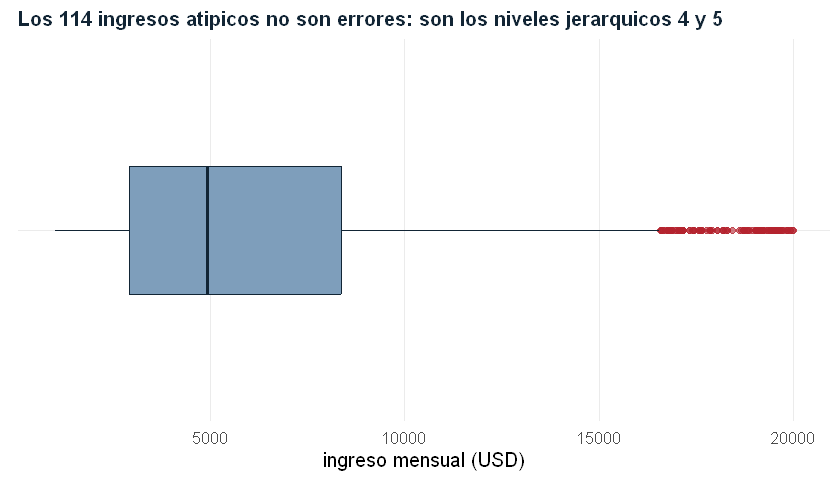

In [23]:
# El boxplot dibuja exactamente la regla del IQR: caja entre Q1 y Q3, atipicos como puntos
p <- ggplot(df, aes(x = MonthlyIncome, y = "")) +
  geom_boxplot(fill = COL[["muted"]], colour = COL[["ink"]],
               outlier.colour = COL[["bad"]], outlier.alpha = 0.6, width = 0.4) +
  labs(title = "Los 114 ingresos atipicos no son errores: son los niveles jerarquicos 4 y 5",
       x = "ingreso mensual (USD)", y = NULL)
guardar_figura("clase02_outliers_ingreso", p)
p

### Que tan estricto es tu umbral?

El 1.5 de la regla es una convencion, no una ley. Mira como cambia la cantidad de empleados señalados como atipicos segun el multiplicador `k` que elijas (en la version Python este experimento es un control deslizante). La leccion: "outlier" depende del umbral, y esa eleccion hay que reportarla.

In [24]:
# Cuantos outliers quedan señalados con cada umbral k
tibble(k = c(1.0, 1.5, 2.0, 2.5, 3.0)) %>%
  rowwise() %>%
  mutate(outliers = sum(df$MonthlyIncome > q3 + k * iqr)) %>%
  ungroup()

k,outliers
<dbl>,<int>
1.0,146
1.5,114
2.0,31
2.5,0
3.0,0


<a name="s7"></a>
## 7. Agrupar para comparar y feature engineering

**La idea.** Las preguntas interesantes casi siempre comparan grupos: se van mas los que hacen horas extra? los que viajan seguido? El combo `group_by` + media de una columna logica responde cualquier "tasa por grupo" en una linea. Y cuando ninguna columna existente captura el fenomeno, se **crea** una variable nueva con sentido sustantivo: eso es feature engineering, y la justificacion viene del dominio, no del algoritmo.

In [25]:
# La comparacion estrella de la clase: attrition segun horas extra
tasa_por_horas_extra <- df %>%
  group_by(OverTime) %>%
  summarise(tasa = mean(AttritionBool))
print(tasa_por_horas_extra %>% mutate(tasa_pct = round(tasa * 100, 1)))

stopifnot(
  abs(tasa_por_horas_extra$tasa[tasa_por_horas_extra$OverTime == "No"] - 0.1044) < 1e-3,
  abs(tasa_por_horas_extra$tasa[tasa_por_horas_extra$OverTime == "Yes"] - 0.3053) < 1e-3
)

# A tibble: 2 × 3
  OverTime  tasa tasa_pct
  <chr>    <dbl>    <dbl>
1 No       0.104     10.4
2 Yes      0.305     30.5


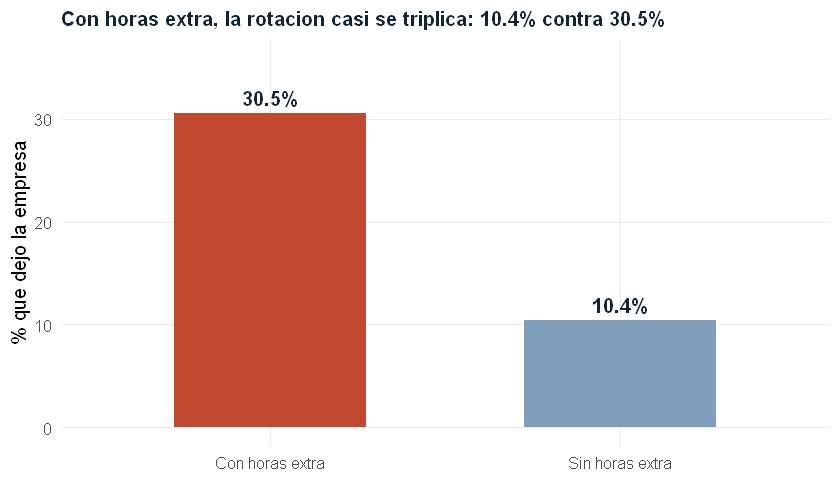

In [26]:
# Figura: la brecha en una imagen
datos_fig <- tasa_por_horas_extra %>%
  mutate(grupo = if_else(OverTime == "Yes", "Con horas extra", "Sin horas extra"),
         pct = tasa * 100)

p <- ggplot(datos_fig, aes(x = grupo, y = pct, fill = grupo)) +
  geom_col(width = 0.55, show.legend = FALSE) +
  geom_text(aes(label = paste0(round(pct, 1), "%")), vjust = -0.5, fontface = "bold",
            colour = COL[["ink"]]) +
  scale_fill_manual(values = c("Con horas extra" = COL[["accent"]],
                               "Sin horas extra" = COL[["muted"]])) +
  scale_y_continuous(limits = c(0, 36)) +
  labs(title = "Con horas extra, la rotacion casi se triplica: 10.4% contra 30.5%",
       x = NULL, y = "% que dejo la empresa")
guardar_figura("clase02_attrition_horas_extra", p)
p

In [27]:
# Otra comparacion con señal: viajar seguido por trabajo
tasa_por_viaje <- df %>%
  group_by(BusinessTravel) %>%
  summarise(tasa = mean(AttritionBool)) %>%
  arrange(tasa)
print(tasa_por_viaje %>% mutate(tasa_pct = round(tasa * 100, 1)))

stopifnot(
  abs(tasa_por_viaje$tasa[tasa_por_viaje$BusinessTravel == "Travel_Frequently"] - 0.2491) < 1e-3,
  abs(tasa_por_viaje$tasa[tasa_por_viaje$BusinessTravel == "Non-Travel"] - 0.0800) < 1e-3
)

# A tibble: 3 × 3
  BusinessTravel     tasa tasa_pct
  <chr>             <dbl>    <dbl>
1 Non-Travel        0.08       8  
2 Travel_Rarely     0.150     15  
3 Travel_Frequently 0.249     24.9


### Crear variables con sentido: dos ejemplos

**Ingreso por año de experiencia.** Dos personas pueden ganar lo mismo con trayectorias muy distintas: 3000 dolares con 2 años de experiencia es una cosa, con 20 años es otra. El cociente captura esa diferencia (sumamos 1 al denominador para que quien recien empieza no divida por cero).

**Tramos de edad.** Para comparar generaciones conviene discretizar la edad con `cut()`, que corta una variable continua en intervalos con etiqueta.

In [28]:
# Feature 1: ingreso mensual por año de experiencia total
# Feature 2: tramos de edad
df <- df %>%
  mutate(
    IngresoPorAnioExp = MonthlyIncome / (TotalWorkingYears + 1),
    TramoEdad = cut(Age, breaks = c(17, 30, 40, 50, 61),
                    labels = c("18-30", "31-40", "41-50", "51-60"))
  )

tasa_por_tramo <- df %>%
  group_by(TramoEdad) %>%
  summarise(tasa = mean(AttritionBool))
print(tasa_por_tramo %>% mutate(tasa_pct = round(tasa * 100, 1)))

stopifnot(
  abs(median(df$IngresoPorAnioExp) - 549.22) < 0.01,
  sum(is.na(df$TramoEdad)) == 0,   # todos los 1470 caen en un tramo
  tasa_por_tramo$tasa[tasa_por_tramo$TramoEdad == "18-30"] >
    tasa_por_tramo$tasa[tasa_por_tramo$TramoEdad == "41-50"]   # los mas jovenes rotan mas
)

# A tibble: 4 × 3
  TramoEdad  tasa tasa_pct
  <fct>     <dbl>    <dbl>
1 18-30     0.259     25.9
2 31-40     0.137     13.7
3 41-50     0.106     10.6
4 51-60     0.126     12.6


<a name="e4"></a>
### Ejercicio 4. Feature engineering: el costo de viajar seguido

Crea la variable logica `ViajaFrecuente` (si `BusinessTravel` es `"Travel_Frequently"`) y calcula la tasa de attrition de quienes viajan frecuente contra el resto. Te tiene que dar, aproximadamente, 24.9% contra 14.1%.

*Pista: es el mismo patron del Ejercicio 2: columna logica + `group_by` + `summarise` con `mean`.*

In [29]:
df <- df %>% mutate(ViajaFrecuente = BusinessTravel == "Travel_Frequently")

tasa_viaje_frec <- df %>%
  group_by(ViajaFrecuente) %>%
  summarise(tasa = mean(AttritionBool))

print(tasa_viaje_frec %>% mutate(tasa_pct = round(tasa * 100, 1)))

stopifnot(
  abs(tasa_viaje_frec$tasa[tasa_viaje_frec$ViajaFrecuente]  - 0.2491) < 1e-3,
  abs(tasa_viaje_frec$tasa[!tasa_viaje_frec$ViajaFrecuente] - 0.1408) < 1e-3
)
cat("Ejercicio 4 correcto\n")

# A tibble: 2 × 3
  ViajaFrecuente  tasa tasa_pct
  <lgl>          <dbl>    <dbl>
1 FALSE          0.141     14.1
2 TRUE           0.249     24.9


Ejercicio 4 correcto


<a name="s8"></a>
## 8. Terminologia: hablar con precision

Hoy hiciste, sin nombrarlas, casi todas las etapas del vocabulario tecnico del programa. El mapa, para que cada termino te quede asociado a algo que ya hiciste:

| termino | que es | donde lo hiciste hoy |
|---|---|---|
| datos crudos | la fuente original, intacta | el CSV de IBM recien cargado |
| limpieza | corregir errores, duplicados, tipos | columnas constantes, duplicados (secciones 4 y 5) |
| procesamiento | manipular: filtrar, agrupar, resumir | `filter`, `group_by` (secciones 4 y 7) |
| preprocesamiento | lo que pide el algoritmo (estandarizar, codificar, imputar) | la imputacion (seccion 5); el resto llega en la Clase 4 |
| feature engineering | crear variables con sentido sustantivo | `IngresoPorAnioExp`, `TramoEdad`, `ViajaFrecuente` (seccion 7) |
| feature selection | elegir que variables entran al modelo | todavia no: llega con los modelos (Clases 4 a 7) |

La distincion no es pedanteria: cuando en la Clase 4 hablemos de *data leakage* vas a ver que confundir preprocesamiento con procesamiento puede invalidar un modelo entero.

<a name="quiz"></a>
## Autoevaluacion

Cuatro preguntas que cruzan toda la clase. Comprometete con una respuesta antes de abrir cada solucion.

**1.** En R, `edades[1]` devuelve el primer elemento. Que devuelve `edades[1]` en Python si `edades = [29, 41, 35]`?

<details><summary>Ver respuesta</summary>

`41`. Python cuenta desde 0: `edades[0]` es 29 y `edades[1]` es 41. Es el tropiezo mas comun al cruzar de R a Python; tenelo presente cuando leas la version Python de esta clase.

</details>

**2.** La media del ingreso (6503) es mayor que la mediana (4919). Que te dice eso de la distribucion, y cual de las dos reportarias?

<details><summary>Ver respuesta</summary>

Asimetria a derecha: pocos ingresos muy altos arrastran la media hacia arriba. Para describir el ingreso "tipico" conviene la mediana, que no se deja arrastrar por la cola.

</details>

**3.** Encontraste 114 ingresos por encima de $Q_3 + 1.5 \times IQR$. Corresponde eliminarlos antes de modelar?

<details><summary>Ver respuesta</summary>

No sin investigarlos. En este dataset todos tienen nivel jerarquico 4 o 5: son gerentes y directores reales, informacion legitima, no errores de carga. Detectar es estadistica; decidir es conocimiento del dominio.

</details>

**4.** Para responder "que departamento tiene mayor tasa de rotacion" en una linea de dplyr, que combinacion usas?

<details><summary>Ver respuesta</summary>

Columna logica + agrupar + media: `df %>% group_by(Department) %>% summarise(tasa = mean(AttritionBool))`. La media de un vector logico es una proporcion; ordenando el resultado ya tenes el ranking (da Sales con 20.6%).

</details>

<a name="cierre"></a>
## Cierre

**Lo que ya podes hacer.** Cargar un CSV desde la nube; explorar un dataset con `dim`, `glimpse`, `summary` y `count`; filtrar, ordenar, renombrar y agrupar; detectar y tratar duplicados, faltantes (eliminar o imputar, global o por grupo) y outliers (regla del IQR mas criterio de dominio); y crear variables nuevas con sentido sustantivo. Es la misma caja de herramientas de la version Python: dos lenguajes, un solo oficio.

**El hallazgo sustantivo de hoy**, por si te lo llevas en una frase: en esta empresa la rotacion se concentra en la gente que hace horas extra (30.5% contra 10.4%), viaja seguido (24.9%) y esta en ventas (39.8% entre representantes). En la Clase 4 vamos a intentar predecirla.

**Para seguir.**

- Wickham y Grolemund, *R para Ciencia de Datos*, caps. 4 a 6: la referencia directa de lo que usaste hoy ([gratis online, en español](https://es.r4ds.hadley.nz/)).
- McKinney, *Python for Data Analysis*, caps. 5 a 7, para el espejo en Python ([gratis online](https://wesmckinney.com/book/)).
- La notebook Python de esta clase, en el sitio de la materia.

## Apendice: Machete dplyr y su espejo pandas

| tarea | en R | en pandas |
|---|---|---|
| cargar CSV desde URL | `read_csv(url)` | `pd.read_csv(url)` |
| dimensiones / tipos | `dim(df)`, `glimpse(df)` | `df.shape`, `df.info()` |
| contar categorias | `count(df, col)` | `df["col"].value_counts()` |
| elegir columnas | `select(df, a, b)` | `df[["a", "b"]]` |
| filtrar filas | `filter(df, cond)` | `df[cond]` |
| ordenar | `arrange(df, desc(a))` | `df.sort_values("a", ascending=False)` |
| duplicados | `sum(duplicated(df))`, `distinct(df)` | `df.duplicated().sum()`, `df.drop_duplicates()` |
| faltantes | `colSums(is.na(df))`, `coalesce(x, v)` | `df.isna().sum()`, `df["c"].fillna(v)` |
| tasa por grupo | `group_by %>% summarise(mean(bool))` | `df.groupby("g")["bool"].mean()` |
| crear variable | `mutate(df, c = a/b)` | `df["c"] = df["a"] / df["b"]` |
| discretizar | `cut(x, breaks, labels)` | `pd.cut(x, bins, labels)` |

---
**Correr / compartir esta notebook.** Abrila en Google Colab con el boton del inicio y elegi *Entorno de ejecucion → Ejecutar todo*; el runtime de R de Colab ya trae tidyverse instalado.

*Datos: IBM HR Analytics Employee Attrition (datos ficticios creados por IBM), servidos desde el [repositorio oficial de IBM](https://github.com/IBM/employee-attrition-aif360). Cada numero de esta pagina se recalcula y verifica con stopifnot() al ejecutar.*